In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),                        # 0-255 → 0.0-1.0, adds channel dim
    transforms.Normalize((0.1307,), (0.3081,))    # MNIST mean & std
])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

print(f"Training samples : {len(train_dataset)}")
print(f"Test     samples : {len(test_dataset)}")

100%|██████████████████████████████████████| 9.91M/9.91M [00:03<00:00, 3.19MB/s]
100%|██████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 70.5kB/s]
100%|███████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 878kB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 6.56MB/s]

Training samples : 60000
Test     samples : 10000


In [11]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.classifier(self.block2(self.block1(x)))

model = CNN().to(device)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

CNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=256, bias=True)
    (2): Batc

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs     = model(images)
            loss        = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total


In [15]:
EPOCHS, PATIENCE = 15, 3
best_val_loss, patience_ctr = float("inf"), 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion, device)
    scheduler.step(val_loss)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch [{epoch:02d}/{EPOCHS}]  Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%  |  Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%")
    if val_loss < best_val_loss:
        best_val_loss, patience_ctr = val_loss, 0
        torch.save(model.state_dict(), "best_cnn_mnist.pth")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

model.load_state_dict(torch.load("best_cnn_mnist.pth"))
print("Best weights restored.")

Epoch [01/15]  Train Loss: 0.1456  Train Acc: 96.00%  |  Val Loss: 0.0292  Val Acc: 99.02%
Epoch [02/15]  Train Loss: 0.0601  Train Acc: 98.19%  |  Val Loss: 0.0202  Val Acc: 99.28%
Epoch [03/15]  Train Loss: 0.0469  Train Acc: 98.54%  |  Val Loss: 0.0207  Val Acc: 99.32%
Epoch [04/15]  Train Loss: 0.0376  Train Acc: 98.88%  |  Val Loss: 0.0163  Val Acc: 99.48%
Epoch [05/15]  Train Loss: 0.0364  Train Acc: 98.86%  |  Val Loss: 0.0187  Val Acc: 99.35%
Epoch [06/15]  Train Loss: 0.0307  Train Acc: 99.03%  |  Val Loss: 0.0179  Val Acc: 99.38%
Epoch [07/15]  Train Loss: 0.0277  Train Acc: 99.09%  |  Val Loss: 0.0183  Val Acc: 99.33%
Early stopping at epoch 7.
Best weights restored.


In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\nTest Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc*100:.2f}%")


Test Loss: 0.0163  |  Test Accuracy: 99.48%


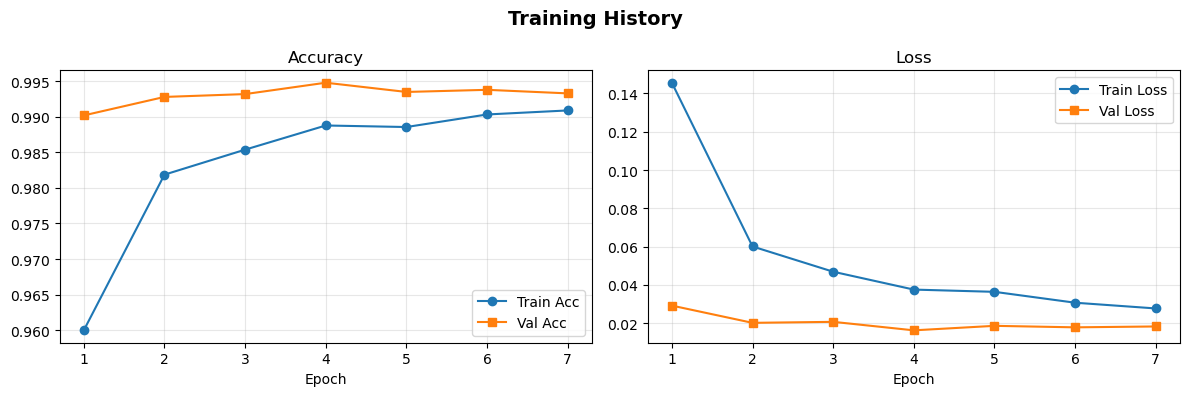

In [ ]:
epochs_ran = range(1, len(history["train_acc"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Training History", fontsize=14, fontweight="bold")
ax1.plot(epochs_ran, history["train_acc"], label="Train Acc", marker="o")
ax1.plot(epochs_ran, history["val_acc"],   label="Val Acc",   marker="s")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(epochs_ran, history["train_loss"], label="Train Loss", marker="o")
ax2.plot(epochs_ran, history["val_loss"],   label="Val Loss",   marker="s")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("training_history.png", dpi=100); plt.show()

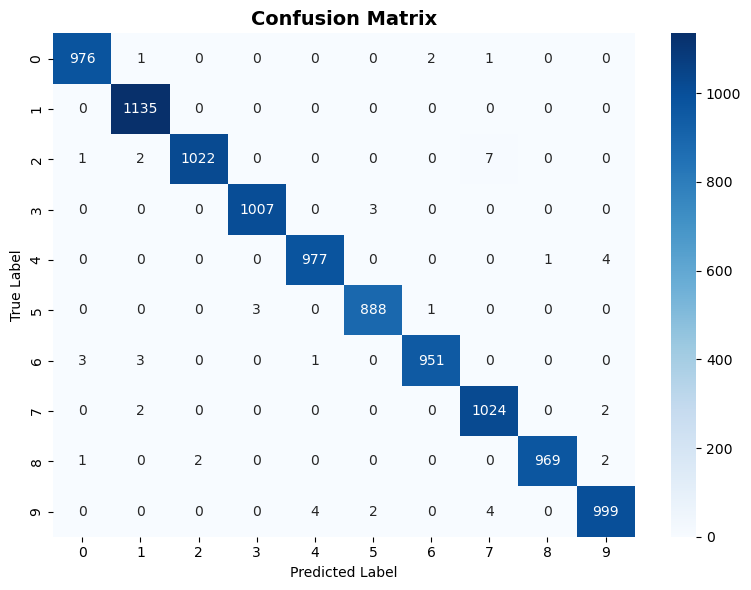


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       0.99      1.00      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        all_preds.extend(model(images.to(device)).argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=100); plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

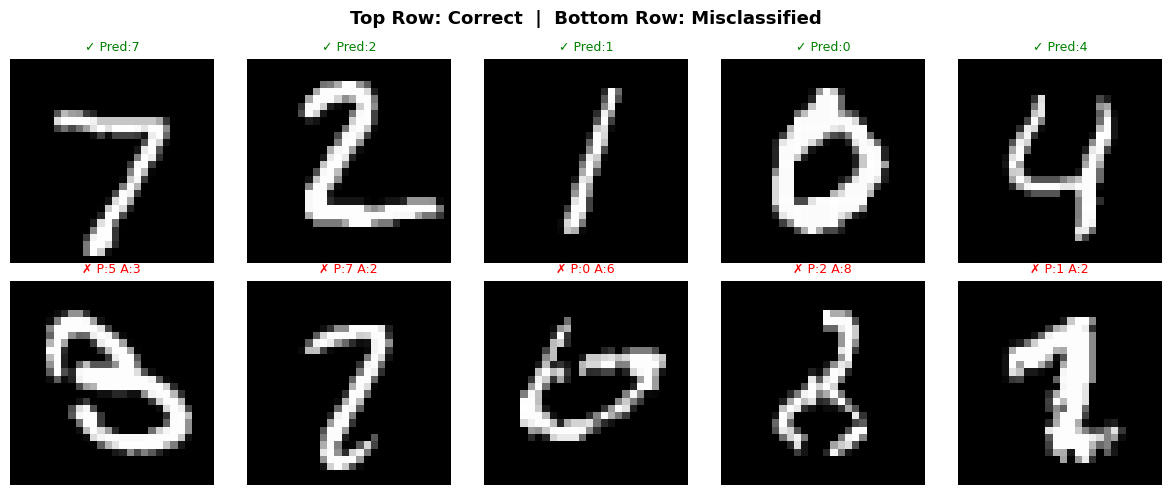

In [20]:
wrong_idx, correct_idx = np.where(all_preds != all_labels)[0], np.where(all_preds == all_labels)[0]
test_images_all = test_dataset.data.numpy()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Top Row: Correct  |  Bottom Row: Misclassified", fontsize=13, fontweight="bold")
for i, ax in enumerate(axes[0]):
    idx = correct_idx[i]; ax.imshow(test_images_all[idx], cmap="gray")
    ax.set_title(f"✓ Pred:{all_preds[idx]}", color="green", fontsize=9); ax.axis("off")
for i, ax in enumerate(axes[1]):
    idx = wrong_idx[i]; ax.imshow(test_images_all[idx], cmap="gray")
    ax.set_title(f"✗ P:{all_preds[idx]} A:{all_labels[idx]}", color="red", fontsize=9); ax.axis("off")
plt.tight_layout(); plt.savefig("predictions.png", dpi=100); plt.show()